In [8]:
from io import StringIO
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [9]:
USGS_ALL_MONTH = "https://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/all_month.csv"
EARTH_RADIUS_KM = 6371.0088



In [10]:
def download_raw_usgs(url=USGS_ALL_MONTH) -> pd.DataFrame:
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    return pd.read_csv(StringIO(r.text))

df_raw = download_raw_usgs()
print("RAW shape:", df_raw.shape)
df_raw.to_csv("raw_all_month.csv", index=False)
print("Saved raw_all_month.csv")
df_raw.head()

RAW shape: (9968, 22)
Saved raw_all_month.csv


,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2026-02-21T03:39:00.020Z,33.653000,-116.717500,15.40,0.49,ml,23,77,0.03975,0.14,...,2026-02-21T03:42:31.097Z,"10 km S of Idyllwild, CA",earthquake,0.26,0.4400,0.118624,8.0,automatic,ci,ci
1,2026-02-21T03:38:28.506Z,64.835000,-149.069000,12.30,1.00,ml,11,109,0.20000,0.60,...,2026-02-21T03:39:50.585Z,"25 km N of Four Mile Road, Alaska",earthquake,4.50,3.1853,0.300000,4.0,automatic,ak,ak
2,2026-02-21T03:21:27.530Z,33.645667,-116.725500,15.26,1.58,ml,87,24,0.04896,0.19,...,2026-02-21T03:32:01.470Z,"11 km S of Idyllwild, CA",earthquake,0.13,0.2700,0.182024,25.0,automatic,ci,ci
3,2026-02-21T03:09:43.060Z,19.192000,-66.487833,23.36,3.28,md,25,259,0.71220,0.27,...,2026-02-21T03:36:40.250Z,"80 km N of Tierras Nuevas Poniente, Puerto Rico",earthquake,0.84,17.6800,0.052903,16.0,reviewed,pr,pr
4,2026-02-21T03:06:52.985Z,62.930000,-151.281000,111.60,1.80,ml,33,99,0.50000,0.60,...,2026-02-21T03:08:47.425Z,"55 km NNW of Petersville, Alaska",earthquake,4.00,3.3570,0.200000,4.0,automatic,ak,ak


In [11]:
# --- Initial Data Inspection (USGS Earthquakes) ---

print("\n--- Initial Data (Head) ---")
display(df_raw.head())

# Columns used in this project (safe even if some columns are missing)
selected_cols = ["id", "time", "latitude", "longitude", "depth", "mag", "place", "type"]
selected_cols = [c for c in selected_cols if c in df_raw.columns]
df_selected = df_raw[selected_cols].copy()

print("\n--- Initial Data (Info for Selected Features) ---")
print(df_selected.info())

print("\n--- Initial Data (Missing Values for Selected Features) ---")
print(df_selected.isnull().sum())

print("\n--- Initial Data (Basic Shape) ---")
print("Rows, Columns:", df_raw.shape)
print("Selected Columns:", df_selected.shape)

# Extra inspection (recommended for report quality)
if "type" in df_selected.columns:
    print("\n--- Event Type Counts (Top 10) ---")
    print(df_selected["type"].value_counts().head(10))

if all(c in df_selected.columns for c in ["mag", "depth"]):
    print("\n--- Summary Stats (mag & depth) ---")
    print(df_selected[["mag", "depth"]].describe())


--- Initial Data (Head) ---


,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2026-02-21T03:39:00.020Z,33.653000,-116.717500,15.40,0.49,ml,23,77,0.03975,0.14,...,2026-02-21T03:42:31.097Z,"10 km S of Idyllwild, CA",earthquake,0.26,0.4400,0.118624,8.0,automatic,ci,ci
1,2026-02-21T03:38:28.506Z,64.835000,-149.069000,12.30,1.00,ml,11,109,0.20000,0.60,...,2026-02-21T03:39:50.585Z,"25 km N of Four Mile Road, Alaska",earthquake,4.50,3.1853,0.300000,4.0,automatic,ak,ak
2,2026-02-21T03:21:27.530Z,33.645667,-116.725500,15.26,1.58,ml,87,24,0.04896,0.19,...,2026-02-21T03:32:01.470Z,"11 km S of Idyllwild, CA",earthquake,0.13,0.2700,0.182024,25.0,automatic,ci,ci
3,2026-02-21T03:09:43.060Z,19.192000,-66.487833,23.36,3.28,md,25,259,0.71220,0.27,...,2026-02-21T03:36:40.250Z,"80 km N of Tierras Nuevas Poniente, Puerto Rico",earthquake,0.84,17.6800,0.052903,16.0,reviewed,pr,pr
4,2026-02-21T03:06:52.985Z,62.930000,-151.281000,111.60,1.80,ml,33,99,0.50000,0.60,...,2026-02-21T03:08:47.425Z,"55 km NNW of Petersville, Alaska",earthquake,4.00,3.3570,0.200000,4.0,automatic,ak,ak



--- Initial Data (Info for Selected Features) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9968 entries, 0 to 9967
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         9968 non-null   object 
 1   time       9968 non-null   object 
 2   latitude   9968 non-null   float64
 3   longitude  9968 non-null   float64
 4   depth      9968 non-null   float64
 5   mag        9967 non-null   float64
 6   place      9968 non-null   object 
 7   type       9968 non-null   object 
dtypes: float64(4), object(4)
memory usage: 623.1+ KB
None

--- Initial Data (Missing Values for Selected Features) ---
id           0
time         0
latitude     0
longitude    0
depth        0
mag          1
place        0
type         0
dtype: int64

--- Initial Data (Basic Shape) ---
Rows, Columns: (9968, 22)
Selected Columns: (9968, 8)

--- Event Type Counts (Top 10) ---
type
earthquake          9819
explosion             69
quarry bl

In [12]:
# --- Column Selection (keep only relevant fields) ---

keep_cols = ["id", "time", "latitude", "longitude", "depth", "mag", "place", "type"]
keep_cols = [c for c in keep_cols if c in df_raw.columns]  # safe if any column missing

df_cols = df_raw[keep_cols].copy()

print("\n--- Columns Retained ---")
print(keep_cols)

print("\n--- Shape After Column Selection ---")
print("Rows, Columns:", df_cols.shape)

print("\n--- Preview After Column Selection (Head) ---")
display(df_cols.head())


--- Columns Retained ---
['id', 'time', 'latitude', 'longitude', 'depth', 'mag', 'place', 'type']

--- Shape After Column Selection ---
Rows, Columns: (9968, 8)

--- Preview After Column Selection (Head) ---


,id,time,latitude,longitude,depth,mag,place,type
0,ci41400888,2026-02-21T03:39:00.020Z,33.653000,-116.717500,15.40,0.49,"10 km S of Idyllwild, CA",earthquake
1,aka2026dpxhdt,2026-02-21T03:38:28.506Z,64.835000,-149.069000,12.30,1.00,"25 km N of Four Mile Road, Alaska",earthquake
2,ci41400872,2026-02-21T03:21:27.530Z,33.645667,-116.725500,15.26,1.58,"11 km S of Idyllwild, CA",earthquake
3,pr71508373,2026-02-21T03:09:43.060Z,19.192000,-66.487833,23.36,3.28,"80 km N of Tierras Nuevas Poniente, Puerto Rico",earthquake
4,aka2026dpwfxy,2026-02-21T03:06:52.985Z,62.930000,-151.281000,111.60,1.80,"55 km NNW of Petersville, Alaska",earthquake


In [13]:
# --- Handling Missing Coordinates (latitude/longitude) ---

before_rows = df_cols.shape[0]

missing_lat = df_cols["latitude"].isna().sum()
missing_lon = df_cols["longitude"].isna().sum()

print("--- Missing Values Before ---")
print("Missing latitude:", missing_lat)
print("Missing longitude:", missing_lon)
print("Rows before:", before_rows)

df_no_missing = df_cols.dropna(subset=["latitude", "longitude"]).copy()

after_rows = df_no_missing.shape[0]
print("\n--- After Dropping Missing Coordinates ---")
print("Rows after:", after_rows)
print("Removed rows:", before_rows - after_rows)

display(df_no_missing.head())

--- Missing Values Before ---
Missing latitude: 0
Missing longitude: 0
Rows before: 9968

--- After Dropping Missing Coordinates ---
Rows after: 9968
Removed rows: 0


,id,time,latitude,longitude,depth,mag,place,type
0,ci41400888,2026-02-21T03:39:00.020Z,33.653000,-116.717500,15.40,0.49,"10 km S of Idyllwild, CA",earthquake
1,aka2026dpxhdt,2026-02-21T03:38:28.506Z,64.835000,-149.069000,12.30,1.00,"25 km N of Four Mile Road, Alaska",earthquake
2,ci41400872,2026-02-21T03:21:27.530Z,33.645667,-116.725500,15.26,1.58,"11 km S of Idyllwild, CA",earthquake
3,pr71508373,2026-02-21T03:09:43.060Z,19.192000,-66.487833,23.36,3.28,"80 km N of Tierras Nuevas Poniente, Puerto Rico",earthquake
4,aka2026dpwfxy,2026-02-21T03:06:52.985Z,62.930000,-151.281000,111.60,1.80,"55 km NNW of Petersville, Alaska",earthquake


In [14]:
# --- Coordinate Range Validation ---

before_rows = df_no_missing.shape[0]

invalid_mask = ~(
    df_no_missing["latitude"].between(-90, 90) &
    df_no_missing["longitude"].between(-180, 180)
)

invalid_count = int(invalid_mask.sum())
print("--- Invalid Coordinate Rows ---")
print("Invalid rows found:", invalid_count)

# Optional: show a few invalid rows (if any)
if invalid_count > 0:
    print("\nSample invalid rows:")
    display(df_no_missing.loc[invalid_mask, ["latitude", "longitude"]].head())

df_valid_coords = df_no_missing.loc[~invalid_mask].copy()

after_rows = df_valid_coords.shape[0]
print("\n--- After Range Validation ---")
print("Rows before:", before_rows)
print("Rows after:", after_rows)
print("Removed rows:", before_rows - after_rows)

display(df_valid_coords.head())

--- Invalid Coordinate Rows ---
Invalid rows found: 0

--- After Range Validation ---
Rows before: 9968
Rows after: 9968
Removed rows: 0


,id,time,latitude,longitude,depth,mag,place,type
0,ci41400888,2026-02-21T03:39:00.020Z,33.653000,-116.717500,15.40,0.49,"10 km S of Idyllwild, CA",earthquake
1,aka2026dpxhdt,2026-02-21T03:38:28.506Z,64.835000,-149.069000,12.30,1.00,"25 km N of Four Mile Road, Alaska",earthquake
2,ci41400872,2026-02-21T03:21:27.530Z,33.645667,-116.725500,15.26,1.58,"11 km S of Idyllwild, CA",earthquake
3,pr71508373,2026-02-21T03:09:43.060Z,19.192000,-66.487833,23.36,3.28,"80 km N of Tierras Nuevas Poniente, Puerto Rico",earthquake
4,aka2026dpwfxy,2026-02-21T03:06:52.985Z,62.930000,-151.281000,111.60,1.80,"55 km NNW of Petersville, Alaska",earthquake


In [15]:
# --- Duplicate Removal (by unique earthquake id) ---

before_rows = df_valid_coords.shape[0]

# Count duplicates before removal
dup_count = int(df_valid_coords.duplicated(subset=["id"]).sum())
unique_ids_before = int(df_valid_coords["id"].nunique())

print("--- Duplicate Check (Before) ---")
print("Rows before:", before_rows)
print("Unique IDs before:", unique_ids_before)
print("Duplicate rows (by id):", dup_count)

# Remove duplicates
df_dedup = df_valid_coords.drop_duplicates(subset=["id"]).copy()

after_rows = df_dedup.shape[0]
unique_ids_after = int(df_dedup["id"].nunique())

print("\n--- After Removing Duplicates ---")
print("Rows after:", after_rows)
print("Unique IDs after:", unique_ids_after)
print("Removed rows:", before_rows - after_rows)

display(df_dedup.head())

--- Duplicate Check (Before) ---
Rows before: 9968
Unique IDs before: 9968
Duplicate rows (by id): 0

--- After Removing Duplicates ---
Rows after: 9968
Unique IDs after: 9968
Removed rows: 0


,id,time,latitude,longitude,depth,mag,place,type
0,ci41400888,2026-02-21T03:39:00.020Z,33.653000,-116.717500,15.40,0.49,"10 km S of Idyllwild, CA",earthquake
1,aka2026dpxhdt,2026-02-21T03:38:28.506Z,64.835000,-149.069000,12.30,1.00,"25 km N of Four Mile Road, Alaska",earthquake
2,ci41400872,2026-02-21T03:21:27.530Z,33.645667,-116.725500,15.26,1.58,"11 km S of Idyllwild, CA",earthquake
3,pr71508373,2026-02-21T03:09:43.060Z,19.192000,-66.487833,23.36,3.28,"80 km N of Tierras Nuevas Poniente, Puerto Rico",earthquake
4,aka2026dpwfxy,2026-02-21T03:06:52.985Z,62.930000,-151.281000,111.60,1.80,"55 km NNW of Petersville, Alaska",earthquake


In [16]:
# --- Data Type Conversion (time -> datetime, mag/depth -> numeric) ---

print("--- Dtypes BEFORE conversion ---")
print(df_dedup[["time", "mag", "depth"]].dtypes)

df_types = df_dedup.copy()

# Convert data types safely
df_types["time"] = pd.to_datetime(df_types["time"], errors="coerce")
df_types["mag"] = pd.to_numeric(df_types["mag"], errors="coerce")
df_types["depth"] = pd.to_numeric(df_types["depth"], errors="coerce")

print("\n--- Dtypes AFTER conversion ---")
print(df_types[["time", "mag", "depth"]].dtypes)

print("\n--- Missing Values AFTER conversion ---")
print(df_types[["time", "mag", "depth"]].isna().sum())

display(df_types.head())

--- Dtypes BEFORE conversion ---
time      object
mag      float64
depth    float64
dtype: object

--- Dtypes AFTER conversion ---
time     datetime64[ns, UTC]
mag                  float64
depth                float64
dtype: object

--- Missing Values AFTER conversion ---
time     0
mag      1
depth    0
dtype: int64


,id,time,latitude,longitude,depth,mag,place,type
0,ci41400888,2026-02-21 03:39:00.020000+00:00,33.653000,-116.717500,15.40,0.49,"10 km S of Idyllwild, CA",earthquake
1,aka2026dpxhdt,2026-02-21 03:38:28.506000+00:00,64.835000,-149.069000,12.30,1.00,"25 km N of Four Mile Road, Alaska",earthquake
2,ci41400872,2026-02-21 03:21:27.530000+00:00,33.645667,-116.725500,15.26,1.58,"11 km S of Idyllwild, CA",earthquake
3,pr71508373,2026-02-21 03:09:43.060000+00:00,19.192000,-66.487833,23.36,3.28,"80 km N of Tierras Nuevas Poniente, Puerto Rico",earthquake
4,aka2026dpwfxy,2026-02-21 03:06:52.985000+00:00,62.930000,-151.281000,111.60,1.80,"55 km NNW of Petersville, Alaska",earthquake


In [17]:
# --- Geospatial Preparation (degrees -> radians for Haversine distance) ---

# Make sure latitude/longitude are numeric first (safe check)
df_geo = df_types.copy()
df_geo["latitude"] = pd.to_numeric(df_geo["latitude"], errors="coerce")
df_geo["longitude"] = pd.to_numeric(df_geo["longitude"], errors="coerce")

# Drop any rows that became NaN after conversion (rare, but safe)
before_rows = df_geo.shape[0]
df_geo = df_geo.dropna(subset=["latitude", "longitude"]).copy()
after_rows = df_geo.shape[0]

print("--- Coordinate Numeric Check ---")
print("Rows before:", before_rows)
print("Rows after dropping NaN coords:", after_rows)
print("Removed rows:", before_rows - after_rows)

# Convert to radians (for Haversine DBSCAN)
coords_deg = df_geo[["latitude", "longitude"]].to_numpy(dtype=float)
coords_rad = np.radians(coords_deg)

print("\n--- Radians Conversion Output ---")
print("coords_rad shape:", coords_rad.shape)
print("First 5 rows (radians):")
print(coords_rad[:5])

# Keep df_geo for later use (labels will be added to this)
display(df_geo.head())

--- Coordinate Numeric Check ---
Rows before: 9968
Rows after dropping NaN coords: 9968
Removed rows: 0

--- Radians Conversion Output ---
coords_rad shape: (9968, 2)
First 5 rows (radians):
[[ 0.58735565 -2.03710467]
 [ 1.13158422 -2.60174486]
 [ 0.58722766 -2.0372443 ]
 [ 0.33496359 -1.1604316 ]
 [ 1.0983357  -2.64035155]]


,id,time,latitude,longitude,depth,mag,place,type
0,ci41400888,2026-02-21 03:39:00.020000+00:00,33.653000,-116.717500,15.40,0.49,"10 km S of Idyllwild, CA",earthquake
1,aka2026dpxhdt,2026-02-21 03:38:28.506000+00:00,64.835000,-149.069000,12.30,1.00,"25 km N of Four Mile Road, Alaska",earthquake
2,ci41400872,2026-02-21 03:21:27.530000+00:00,33.645667,-116.725500,15.26,1.58,"11 km S of Idyllwild, CA",earthquake
3,pr71508373,2026-02-21 03:09:43.060000+00:00,19.192000,-66.487833,23.36,3.28,"80 km N of Tierras Nuevas Poniente, Puerto Rico",earthquake
4,aka2026dpwfxy,2026-02-21 03:06:52.985000+00:00,62.930000,-151.281000,111.60,1.80,"55 km NNW of Petersville, Alaska",earthquake


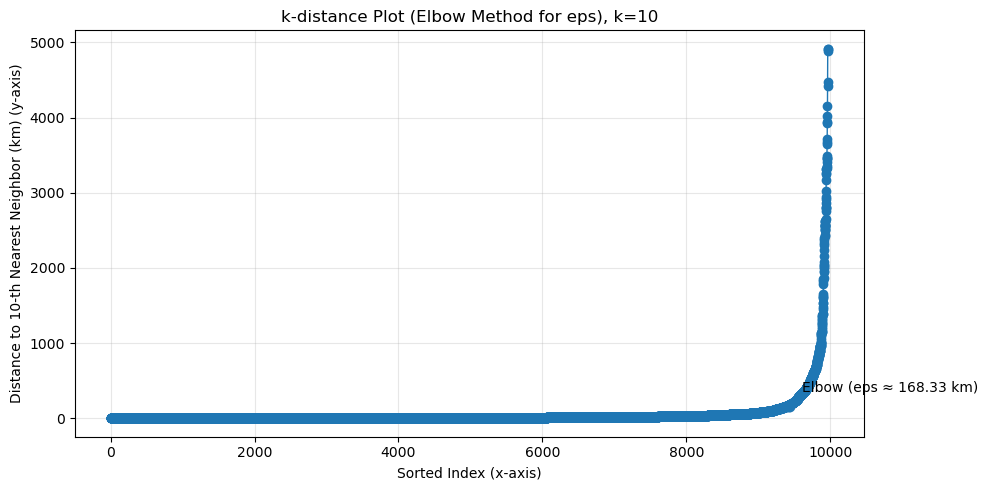

Suggested eps_km: 168.33411795813203


In [18]:
def estimate_elbow_index(sorted_vals: np.ndarray) -> int:
    x = np.arange(len(sorted_vals))
    y = sorted_vals
    x1, y1 = x[0], y[0]
    x2, y2 = x[-1], y[-1]
    num = np.abs((y2 - y1) * x - (x2 - x1) * y + (x2 * y1 - y2 * x1))
    den = np.sqrt((y2 - y1) ** 2 + (x2 - x1) ** 2)
    dist = num / den
    return int(np.argmax(dist))

def k_distance_plot_haversine(coords_rad: np.ndarray, k: int = 10, show_elbow: bool = True):
    nn = NearestNeighbors(n_neighbors=k, metric="haversine")
    nn.fit(coords_rad)
    distances, _ = nn.kneighbors(coords_rad)

    k_dist_rad = distances[:, k-1]
    k_dist_km = k_dist_rad * EARTH_RADIUS_KM
    k_sorted = np.sort(k_dist_km)

    elbow_idx = estimate_elbow_index(k_sorted)
    elbow_eps = k_sorted[elbow_idx]

    plt.figure(figsize=(10, 5))
    plt.plot(np.arange(len(k_sorted)), k_sorted, marker="o", linewidth=1)
    plt.xlabel("Sorted Index (x-axis)")
    plt.ylabel(f"Distance to {k}-th Nearest Neighbor (km) (y-axis)")
    plt.title(f"k-distance Plot (Elbow Method for eps), k={k}")

    if show_elbow:
        plt.scatter([elbow_idx], [elbow_eps], s=60)
        plt.annotate(f"Elbow (eps ≈ {elbow_eps:.2f} km)",
                     (elbow_idx, elbow_eps),
                     textcoords="offset points",
                     xytext=(10, 10))

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return elbow_eps, elbow_idx

min_samples = 10
suggested_eps_km, elbow_idx = k_distance_plot_haversine(coords_rad, k=min_samples, show_elbow=True)
print("Suggested eps_km:", suggested_eps_km)


In [22]:
import numpy as np
from sklearn.metrics import silhouette_score, davies_bouldin_score

def metrics(coords_rad, labels):
    """
    coords_rad: numpy array (N,2) in radians
    labels: cluster labels from DBSCAN (-1 = noise)
    Returns: dict with clusters, noise_pct, silhouette, davies_bouldin
    """
    labels = np.asarray(labels)
    n = labels.size

    # clusters excluding noise
    clusters = len(set(labels)) - (1 if -1 in set(labels) else 0)
    noise_pct = (labels == -1).sum() * 100.0 / n

    # compute metrics only on non-noise points
    mask = labels != -1
    X = coords_rad[mask]
    y = labels[mask]

    sil = None
    dbi = None
    # need at least 2 clusters to compute these
    if len(set(y)) >= 2 and len(y) >= 2:
        sil = float(silhouette_score(X, y))
        dbi = float(davies_bouldin_score(X, y))

    return {
        "clusters": clusters,
        "noise_pct": float(noise_pct),
        "silhouette": sil,
        "davies_bouldin": dbi
    }

In [23]:
eps_km = 168.33
min_samples = 10

labels, core_idx, _ = run_dbscan_haversine(coords_rad, eps_km, min_samples)

m = metrics(coords_rad, labels)
print("eps_km:", eps_km, "min_samples:", min_samples)
print("clusters:", m["clusters"])
print("noise%:", m["noise_pct"])
print("silhouette:", m["silhouette"])
print("davies_bouldin:", m["davies_bouldin"])

eps_km: 168.33 min_samples: 10
clusters: 25
noise%: 4.715088282504013
silhouette: 0.4664335753167568
davies_bouldin: 0.30865727797125353


In [25]:
# --- Parameter Sweep Output Table ---

eps_list = [80, 100, 120, 140, 160, 168.33, 180, 200]     # you can adjust
min_samples_list = [5, 8, 10, 12, 15]

rows = []
for ms in min_samples_list:
    for eps in eps_list:
        labels, core_idx, _ = run_dbscan_haversine(coords_rad, eps, ms)
        m = metrics(coords_rad, labels)
        rows.append({
            "eps_km": eps,
            "min_samples": ms,
            "clusters": m["clusters"],
            "noise_pct": m["noise_pct"],
            "silhouette": m["silhouette"],
            "davies_bouldin": m["davies_bouldin"]
        })

sweep_df = pd.DataFrame(rows)
sweep_df

,eps_km,min_samples,clusters,noise_pct,silhouette,davies_bouldin
0,80.00,5,39,5.708266,0.258668,2.273129
1,100.00,5,38,5.106340,0.267106,2.131972
2,120.00,5,40,4.494382,0.196692,1.593456
3,140.00,5,42,3.832263,0.286899,1.054870
4,160.00,5,38,3.400883,0.621217,1.618223
5,168.33,5,40,3.260433,0.620788,1.658859
6,180.00,5,41,3.039727,0.643303,1.670613
7,200.00,5,40,2.698636,0.640440,1.686855
8,80.00,8,27,7.022472,0.250630,3.037591
9,100.00,8,30,5.808587,0.264490,2.456785


In [28]:
# --- Top 10 Ranked Results ---

rank_df = sweep_df.copy()

# Remove rows where silhouette/davies is None (happens when <2 clusters)
rank_df = rank_df.dropna(subset=["silhouette", "davies_bouldin"])

# Sort: best silhouette (high), then best DB (low), then noise (low)
top10 = rank_df.sort_values(
    by=["silhouette", "davies_bouldin", "noise_pct"],
    ascending=[False, True, True]
).head(10)

top10

,eps_km,min_samples,clusters,noise_pct,silhouette,davies_bouldin
39,200.00,15,17,5.367175,0.652576,0.283377
31,200.00,12,19,5.046148,0.652438,0.278020
22,180.00,10,25,4.464286,0.651545,0.284883
23,200.00,10,26,4.153291,0.651172,0.299152
14,180.00,8,26,4.113162,0.644436,1.866923
15,200.00,8,24,3.942616,0.643590,1.873421
6,180.00,5,41,3.039727,0.643303,1.670613
7,200.00,5,40,2.698636,0.640440,1.686855
4,160.00,5,38,3.400883,0.621217,1.618223
5,168.33,5,40,3.260433,0.620788,1.658859


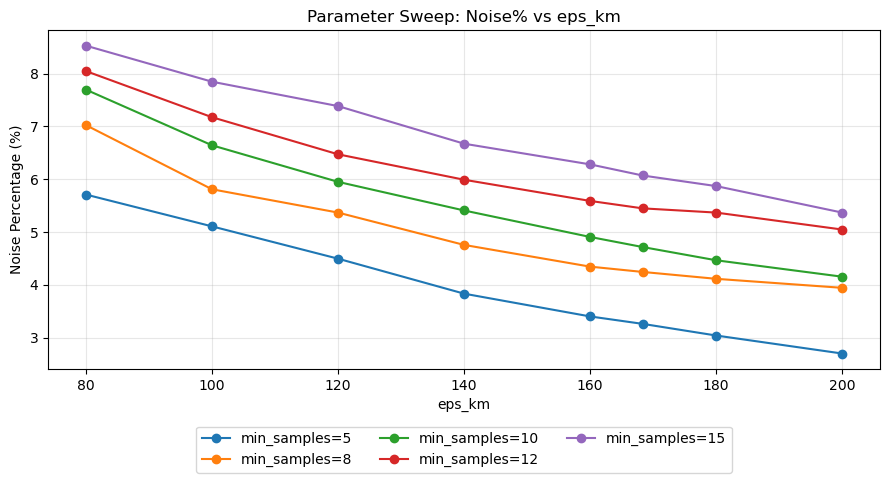

In [29]:
# --- Plot: Noise% vs eps (for each min_samples) ---

plt.figure(figsize=(9,5))

for ms in min_samples_list:
    subset = sweep_df[sweep_df["min_samples"] == ms].sort_values("eps_km")
    plt.plot(subset["eps_km"], subset["noise_pct"], marker="o", label=f"min_samples={ms}")

plt.title("Parameter Sweep: Noise% vs eps_km")
plt.xlabel("eps_km")
plt.ylabel("Noise Percentage (%)")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=True)
plt.tight_layout()
plt.show()

In [30]:
import numpy as np
from sklearn.metrics import silhouette_score, davies_bouldin_score

def compute_dbscan_metrics(coords_rad, labels):
    labels = np.asarray(labels)
    n = len(labels)

    # Number of clusters (exclude noise label -1)
    num_clusters = len(set(labels)) - (1 if -1 in set(labels) else 0)

    # Noise percentage
    noise_pct = (labels == -1).sum() * 100.0 / n

    # Compute silhouette & DB index on non-noise points only
    mask = labels != -1
    X = coords_rad[mask]
    y = labels[mask]

    sil = None
    dbi = None
    if len(set(y)) >= 2 and len(y) >= 2:
        sil = float(silhouette_score(X, y))
        dbi = float(davies_bouldin_score(X, y))

    return {
        "clusters": num_clusters,
        "noise_pct": float(noise_pct),
        "silhouette": sil,
        "davies_bouldin": dbi
    }

# Example: use your final model outputs
m = compute_dbscan_metrics(coords_rad, labels)

print("--- DBSCAN Metrics (Internal Evaluation) ---")
print("Number of clusters:", m["clusters"])
print("Noise percentage (%):", m["noise_pct"])
print("Silhouette score (excluding noise):", m["silhouette"])
print("Davies–Bouldin index (excluding noise):", m["davies_bouldin"])

--- DBSCAN Metrics (Internal Evaluation) ---
Number of clusters: 17
Noise percentage (%): 5.367174959871589
Silhouette score (excluding noise): 0.6525762989201525
Davies–Bouldin index (excluding noise): 0.28337671845864093


In [31]:
import pandas as pd

results_table = pd.DataFrame([{
    "eps_km": 168.33,
    "min_samples": 10,
    "clusters": m["clusters"],
    "noise%": m["noise_pct"],
    "silhouette": m["silhouette"],
    "davies_bouldin": m["davies_bouldin"]
}])

results_table

,eps_km,min_samples,clusters,noise%,silhouette,davies_bouldin
0,168.33,10,17,5.367175,0.652576,0.283377


In [32]:
import pandas as pd

# Put your final chosen parameters here
eps_km = 168.33
min_samples = 10

# If you already computed m = compute_dbscan_metrics(coords_rad, labels)
# then this will work. Otherwise, compute m first using the earlier metrics code.

metrics_matrix = pd.DataFrame(
    {
        "Value": [
            eps_km,
            min_samples,
            m["clusters"],
            round(m["noise_pct"], 3),
            None if m["silhouette"] is None else round(m["silhouette"], 3),
            None if m["davies_bouldin"] is None else round(m["davies_bouldin"], 3),
        ]
    },
    index=[
        "eps_km",
        "min_samples",
        "Number of clusters",
        "Noise percentage (%)",
        "Silhouette score (non-noise)",
        "Davies–Bouldin index (non-noise)",
    ],
)

metrics_matrix

,Value
eps_km,168.330
min_samples,10.000
Number of clusters,17.000
Noise percentage (%),5.367
Silhouette score (non-noise),0.653
Davies–Bouldin index (non-noise),0.283


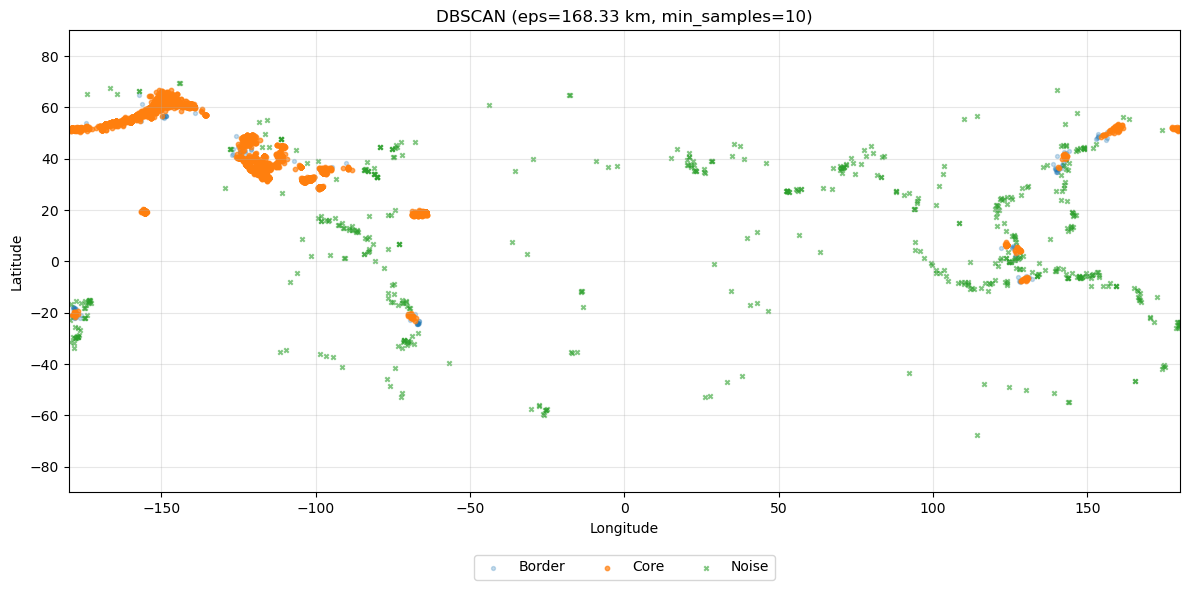

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_core_border_noise(df: pd.DataFrame, core_idx: np.ndarray, title: str = ""):
    n = len(df)
    is_core = np.zeros(n, dtype=bool)
    is_core[core_idx] = True

    if "cluster" not in df.columns:
        raise ValueError("df must contain a 'cluster' column. Add df['cluster']=labels first.")

    is_noise = df["cluster"].to_numpy() == -1
    is_border = (~is_noise) & (~is_core)

    plt.figure(figsize=(12, 6))

    plt.scatter(df.loc[is_border, "longitude"], df.loc[is_border, "latitude"],
                s=8, alpha=0.25, label="Border")

    plt.scatter(df.loc[is_core, "longitude"], df.loc[is_core, "latitude"],
                s=10, alpha=0.7, label="Core")

    plt.scatter(df.loc[is_noise, "longitude"], df.loc[is_noise, "latitude"],
                s=10, marker="x", alpha=0.6, label="Noise")

    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title(title if title else "DBSCAN: Core vs Border vs Noise")
    plt.xlim(-180, 180)
    plt.ylim(-90, 90)
    plt.grid(True, alpha=0.3)
    plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3, frameon=True)
    plt.tight_layout()
    plt.show()

# ---- Pick the correct cleaned dataframe (use your final one) ----
# Usually you have df_geo as the cleaned dataframe for plotting
if "df_geo" in globals():
    df_plot = df_geo.copy()
elif "df_types" in globals():
    df_plot = df_types.copy()
elif "df_dedup" in globals():
    df_plot = df_dedup.copy()
else:
    raise NameError("No suitable dataframe found. Use df_geo/df_types/df_dedup.")

# ---- Make sure labels are attached ----
df_plot["cluster"] = labels  # labels from your DBSCAN run

plot_core_border_noise(
    df_plot,
    core_idx,
    title=f"DBSCAN (eps={eps_km:.2f} km, min_samples={min_samples})"
)


--- Top Clusters (by size) ---
cluster
0    4143
1    3119
4     801
Name: count, dtype: int64


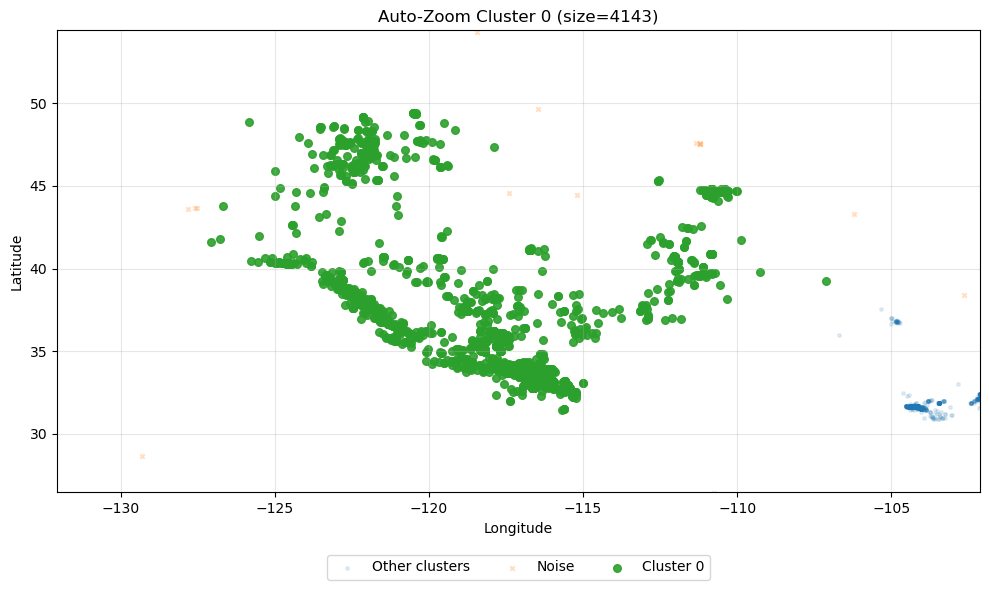

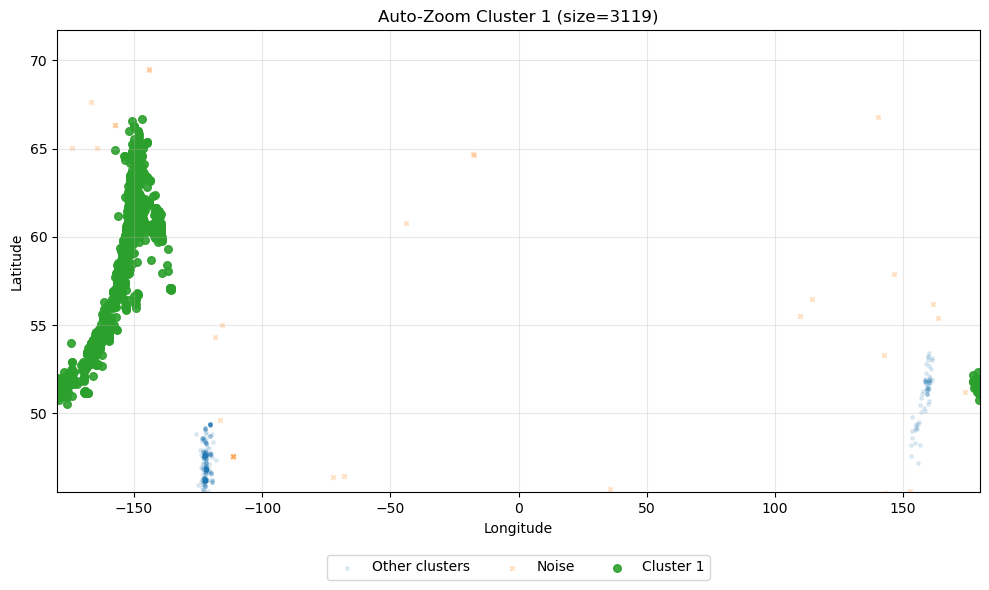

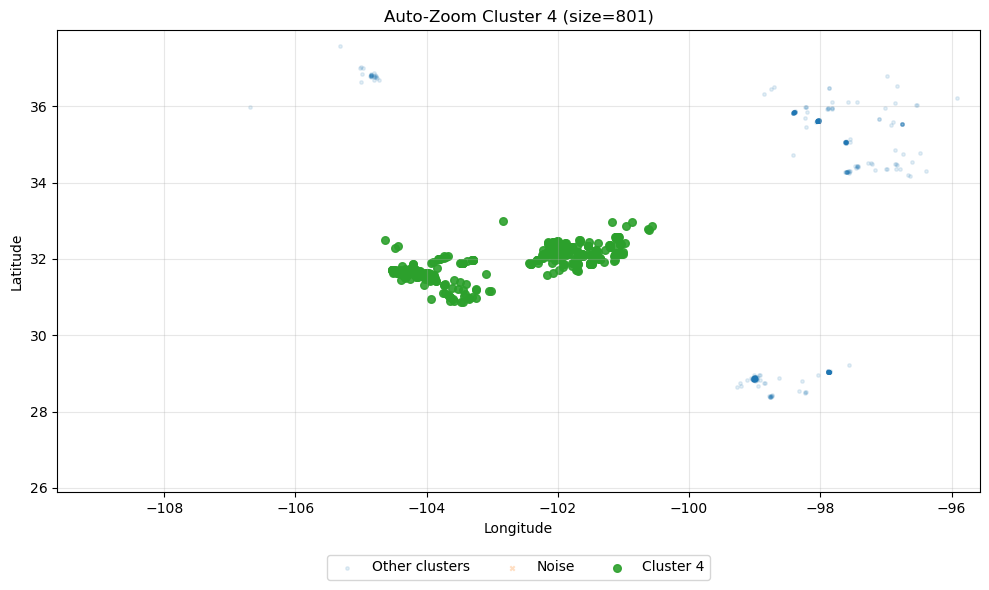

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def auto_bounds(lon: np.ndarray, lat: np.ndarray, margin_deg: float = 5.0):
    xmin, xmax = float(np.min(lon)), float(np.max(lon))
    ymin, ymax = float(np.min(lat)), float(np.max(lat))

    xmin -= margin_deg; xmax += margin_deg
    ymin -= margin_deg; ymax += margin_deg

    # clamp to valid world bounds
    xmin = max(-180, xmin); xmax = min(180, xmax)
    ymin = max(-90, ymin);  ymax = min(90, ymax)
    return xmin, xmax, ymin, ymax


def show_top_clusters(df: pd.DataFrame, top_n: int = 10):
    """
    Returns a Series: cluster_id -> count (excluding noise=-1)
    """
    vc = df.loc[df["cluster"] != -1, "cluster"].value_counts().head(top_n)
    print("\n--- Top Clusters (by size) ---")
    print(vc)
    return vc


def plot_highlight_cluster_zoom(df: pd.DataFrame, cluster_id: int, margin_deg: float = 5.0):
    """
    Zoom plot showing:
    - selected cluster (highlight)
    - other clusters (faint)
    - noise (x)
    """
    selected = df[df["cluster"] == cluster_id]
    if selected.empty:
        print(f"Cluster {cluster_id} not found.")
        return

    others = df[(df["cluster"] != cluster_id) & (df["cluster"] != -1)]
    noise  = df[df["cluster"] == -1]

    xmin, xmax, ymin, ymax = auto_bounds(
        selected["longitude"].to_numpy(),
        selected["latitude"].to_numpy(),
        margin_deg=margin_deg
    )

    plt.figure(figsize=(10, 6))

    if not others.empty:
        plt.scatter(others["longitude"], others["latitude"],
                    s=6, alpha=0.12, label="Other clusters")

    if not noise.empty:
        plt.scatter(noise["longitude"], noise["latitude"],
                    s=10, marker="x", alpha=0.25, label="Noise")

    plt.scatter(selected["longitude"], selected["latitude"],
                s=30, alpha=0.9, label=f"Cluster {cluster_id}")

    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title(f"Auto-Zoom Cluster {cluster_id} (size={len(selected)})")
    plt.xlim(xmin, xmax)
    plt.ylim(ymin, ymax)
    plt.grid(True, alpha=0.3)

    plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3, frameon=True)
    plt.tight_layout()
    plt.show()


def plot_top_clusters_zoom(df: pd.DataFrame, top_k: int = 3, margin_deg: float = 5.0):
    """
    Plots zoomed maps for the top_k largest clusters (excluding noise).
    """
    top_series = show_top_clusters(df, top_n=top_k)
    for cid in top_series.index:
        plot_highlight_cluster_zoom(df, int(cid), margin_deg=margin_deg)


# ---- USAGE ----
# df_plot must contain: latitude, longitude, cluster
# Example: plot top 3 clusters
plot_top_clusters_zoom(df_plot, top_k=3, margin_deg=5.0)

In [39]:
def run_dbscan_once(coords_rad, eps_km, min_samples):
    labels, core_idx, _ = run_dbscan_haversine(coords_rad, eps_km=float(eps_km), min_samples=int(min_samples))
    return labels, core_idx

def clustering_metrics(coords_rad, labels):
    n = len(labels)
    noise = int((labels == -1).sum())
    clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_pct = (noise / n) * 100 if n else 0

    mask = labels != -1
    coords_nn = coords_rad[mask]
    labels_nn = labels[mask]

    sil = None
    dbi = None
    if len(set(labels_nn.tolist())) >= 2:
        sil = float(silhouette_score(coords_nn, labels_nn, metric="euclidean"))
        dbi = float(davies_bouldin_score(coords_nn, labels_nn))

    return clusters, noise_pct, sil, dbi

def parameter_sweep(coords_rad,
                    eps_list=(20, 30, 40, 50, 60, 80, 100, 120, 150),
                    min_samples_list=(6, 10, 15)):
    rows = []
    for ms in min_samples_list:
        for eps in eps_list:
            labels, _ = run_dbscan_once(coords_rad, eps_km=eps, min_samples=ms)
            clusters, noise_pct, sil, dbi = clustering_metrics(coords_rad, labels)
            rows.append({
                "eps_km": float(eps),
                "min_samples": int(ms),
                "clusters": int(clusters),
                "noise_pct": float(noise_pct),
                "silhouette": sil,
                "davies_bouldin": dbi
            })
    return pd.DataFrame(rows)

results_df = parameter_sweep(coords_rad)
results_df


,eps_km,min_samples,clusters,noise_pct,silhouette,davies_bouldin
0,20.0,6,104,17.195024,0.496959,0.367326
1,30.0,6,77,12.861156,0.545282,0.348583
2,40.0,6,69,10.082263,0.471679,0.650681
3,50.0,6,52,8.447030,0.277180,2.967777
4,60.0,6,49,7.353531,0.056321,2.778243
5,80.0,6,36,6.049358,0.257200,2.387626
6,100.0,6,35,5.417335,0.205974,2.413890
7,120.0,6,36,4.825441,0.196053,0.508723
8,150.0,6,33,4.213483,0.286695,1.030217
9,20.0,10,79,21.849920,0.595508,0.337549


In [40]:
def choose_best(results: pd.DataFrame, max_noise_pct: float = 60.0):
    df = results.copy()
    df = df[df["silhouette"].notna()].copy()
    df = df[df["noise_pct"] <= max_noise_pct].copy()

    df["score"] = (
        df["silhouette"] * 1.0
        - (df["noise_pct"] / 100.0) * 0.4
        - (df["davies_bouldin"].fillna(df["davies_bouldin"].max()) / 10.0) * 0.2
    )

    df = df.sort_values("score", ascending=False).reset_index(drop=True)
    return df

ranked_df = choose_best(results_df, max_noise_pct=60.0)
ranked_df.head(10)


,eps_km,min_samples,clusters,noise_pct,silhouette,davies_bouldin,score
0,50.0,15,35,13.503210,0.673128,0.273936,0.613637
1,60.0,15,34,10.914928,0.634834,0.358294,0.584008
2,30.0,15,46,19.271669,0.654389,0.293716,0.571428
3,40.0,15,36,15.971108,0.639197,0.252384,0.570265
4,20.0,15,62,26.825843,0.683785,0.357293,0.569336
5,50.0,10,48,10.704254,0.584824,0.611565,0.529776
6,40.0,10,53,12.931380,0.579371,0.305377,0.521538
7,20.0,10,79,21.849920,0.595508,0.337549,0.501357
8,30.0,6,77,12.861156,0.545282,0.348583,0.486865
9,150.0,15,19,6.360353,0.460037,0.299889,0.428598


In [42]:
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score, davies_bouldin_score

def clustering_metrics(coords_rad, labels):
    labels = np.asarray(labels)
    n = len(labels)

    noise = int((labels == -1).sum())
    clusters = len(set(labels)) - (1 if -1 in set(labels) else 0)
    noise_pct = (noise / n) * 100 if n else 0

    mask = labels != -1
    X = coords_rad[mask]
    y = labels[mask]

    sil = None
    dbi = None

    # silhouette requires at least 2 clusters
    if len(y) > 1 and len(set(y)) >= 2:
        sil = float(silhouette_score(X, y, metric="haversine"))  
        dbi = float(davies_bouldin_score(X, y))                  

    return clusters, noise_pct, sil, dbi

In [43]:
def parameter_sweep(coords_rad, eps_list, min_samples_list):
    rows = []
    for ms in min_samples_list:
        for eps in eps_list:
            labels, core_idx, _ = run_dbscan_haversine(coords_rad, eps_km=float(eps), min_samples=int(ms))
            clusters, noise_pct, sil, dbi = clustering_metrics(coords_rad, labels)
            rows.append({
                "eps_km": float(eps),
                "min_samples": int(ms),
                "clusters": int(clusters),
                "noise_pct": float(noise_pct),
                "silhouette": sil,
                "davies_bouldin": dbi
            })
    return pd.DataFrame(rows)

eps_list = [80, 100, 120, 140, 160, 168.33, 180, 200]
min_samples_list = [5, 8, 10, 12, 15]

sweep_df = parameter_sweep(coords_rad, eps_list, min_samples_list)
sweep_df.head()

,eps_km,min_samples,clusters,noise_pct,silhouette,davies_bouldin
0,80.0,5,39,5.708266,0.348274,2.273129
1,100.0,5,38,5.106340,0.356422,2.131972
2,120.0,5,40,4.494382,0.304806,1.593456
3,140.0,5,42,3.832263,0.372716,1.054870
4,160.0,5,38,3.400883,0.642461,1.618223


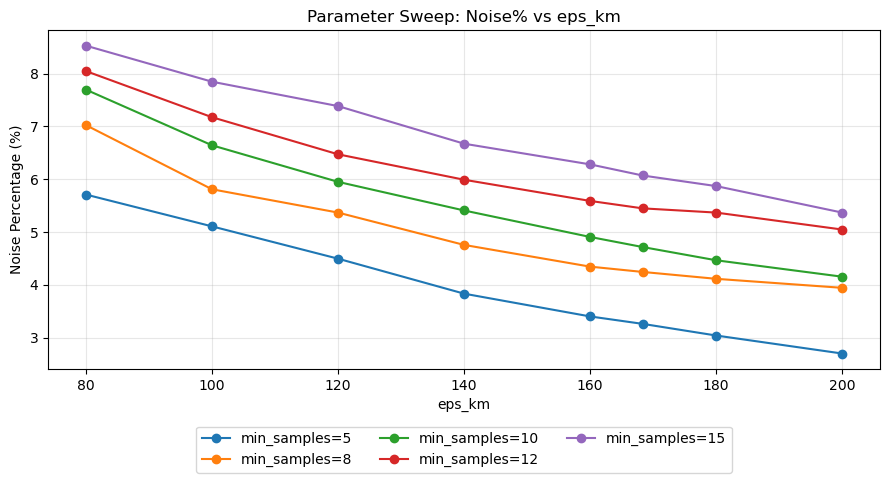

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))
for ms in min_samples_list:
    subset = sweep_df[sweep_df["min_samples"] == ms].sort_values("eps_km")
    plt.plot(subset["eps_km"], subset["noise_pct"], marker="o", label=f"min_samples={ms}")

plt.title("Parameter Sweep: Noise% vs eps_km")
plt.xlabel("eps_km")
plt.ylabel("Noise Percentage (%)")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=True)
plt.tight_layout()
plt.show()

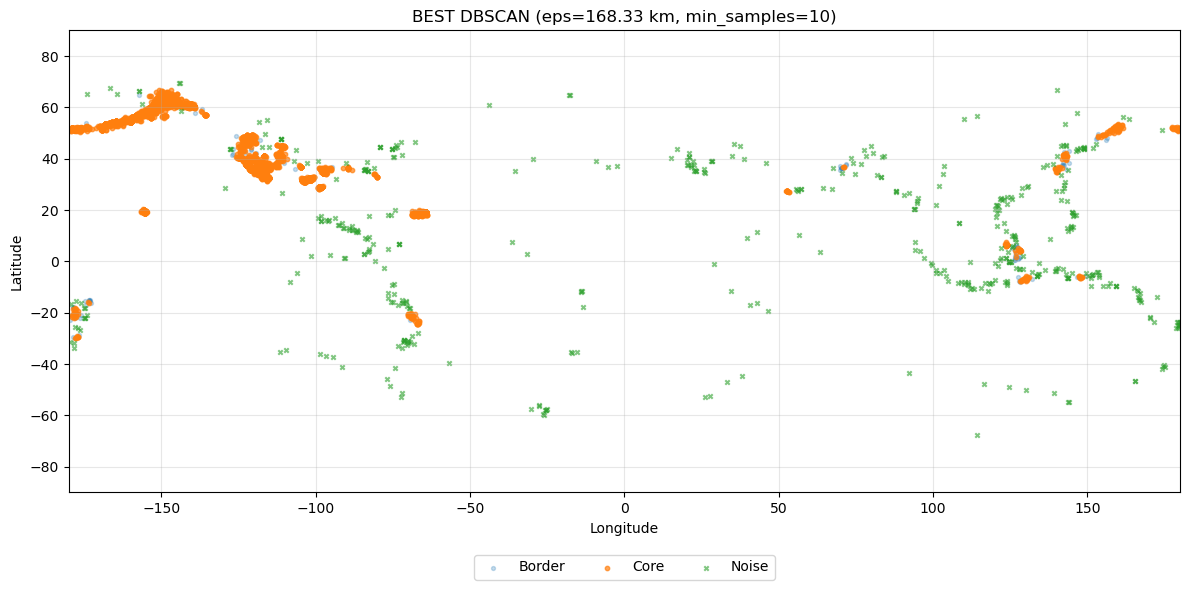

In [48]:
# ---- Final chosen parameters (from your results) ----
best_eps = 168.33
best_ms  = 10

# ---- Use your cleaned dataframe (usually df_geo) ----
df_best = df_geo.copy()   # replace df_geo with your cleaned df name if different

# ---- Run DBSCAN and attach labels ----
best_labels, best_core_idx, best_model = run_dbscan_haversine(coords_rad, best_eps, best_ms)
df_best["cluster"] = best_labels

# ---- Plot core/border/noise ----
plot_core_border_noise(df_best, best_core_idx,
                       title=f"BEST DBSCAN (eps={best_eps} km, min_samples={best_ms})")